# Iterative-$\alpha$ Pauli Correlation Encoding for Optimized Quantum Neural Networks (I$\alpha$PCE-QNN)

**Author:** Aniekan Afangideh — Department of Computer Engineering, University of Uyo, Nigeria

This notebook implements an **Iterative-$\alpha$ Pauli Correlation Encoding (I$\alpha$PCE)** scheme and uses it to enhance the **state-preparation and readout** stages of a hybrid Quantum Neural Network (QNN).

## Background

Most variational quantum models assume a **one-to-one mapping** between problem variables (features) and qubits, which quickly exhausts near-term hardware. **Pauli Correlation Encoding (PCE)** [Sciorilli et al., *Nat. Commun.* 16, 476 (2025)] instead maps each classical variable $x_i$ to a $k$-body Pauli string $\Pi_i$ over $n$ qubits, so that

$$m = 3\binom{n}{k} \;\;\Rightarrow\;\; n = \mathcal{O}\!\left(m^{1/k}\right),$$

a *polynomial compression* of qubit requirements. Variables are decoded from the quantum state via

$$x_i = \mathrm{sgn}\big(\langle \Pi_i \rangle\big),$$

and during optimization the hard sign is relaxed to a smooth surrogate $\tanh(\alpha \langle \Pi_i \rangle)$, where $\alpha$ controls the sharpness of the relaxation (Soloviev & Krompiec, 2025, use $\alpha = n^{\lfloor k/2 \rfloor}$). PCE has been demonstrated for Max-Cut on IBM hardware ([IBM Quantum tutorial](https://quantum.cloud.ibm.com/docs/en/tutorials/pauli-correlation-encoding-for-qaoa)) and for large-scale portfolio optimization (Soloviev & Krompiec, 2025).

## Contribution of this notebook

We transfer PCE from combinatorial optimization to **quantum machine learning**:

1. **PCE-guided state preparation.** $m$ classical features are injected into only $n = \mathcal{O}(m^{1/k})$ qubits through Pauli-string rotations $e^{-i\, x_i \beta\, \Pi_i}$ — one rotation per feature, one Pauli string per feature.
2. **PCE readout.** The hidden representation of the QNN is the vector $z_i = \tanh(\alpha\langle\Pi_i\rangle)$, $i = 1,\dots,m$, read from the *same* Pauli strings.
3. **Iterative-$\alpha$ training (the I$\alpha$ part).** Instead of fixing $\alpha$, we **anneal it over training stages** $\alpha_1 < \alpha_2 < \dots < \alpha_T$, warm-starting each stage from the previous optimum. Small $\alpha$ keeps the loss landscape smooth and trainable early on; large $\alpha$ progressively sharpens the readout toward the binary sign regime that PCE ultimately targets. This mirrors curriculum/warm-up strategies used elsewhere (e.g., curriculum-based pruning warm-up in efficient vision–language models).

## Logic flow

```
 features x ∈ R^m ──► assign Pauli strings Π_1..Π_m over n = O(m^{1/k}) qubits
        │
        ▼
 STATE PREPARATION:  |ψ(x,θ)⟩ = HEA(θ) · ∏_i exp(-i x_i β Π_i) · |init⟩
        │
        ▼
 READOUT:            z_i = tanh(α ⟨ψ|Π_i|ψ⟩)        (m correlation features)
        │
        ▼
 CLASSICAL HEAD:     ŷ = σ(w·z + b)                  (logistic layer)
        │
        ▼
 ITERATIVE-α LOOP:   for α in [α_1 < α_2 < ... < α_T]: re-optimize θ (warm start)
```


## 1. Setup

In [1]:
pip install qiskit pylatexenc

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import combinations
from math import comb, floor
from scipy.optimize import minimize

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Qiskit is used for Pauli-operator algebra and circuit visualization.
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp

rng = np.random.default_rng(7)
plt.rcParams["figure.dpi"] = 110
print("Setup complete.")

Setup complete.


## 2. PCE machinery: Pauli strings and qubit compression

Each binary/continuous variable is assigned one $k$-body Pauli string. Following Sciorilli et al. (2025), we draw strings from three mutually-commuting families — permutations of $X^{\otimes k}\!\otimes I^{\,n-k}$, $Y^{\otimes k}\!\otimes I^{\,n-k}$ and $Z^{\otimes k}\!\otimes I^{\,n-k}$ — so all $m$ correlations are measurable with only **three measurement settings** on hardware.

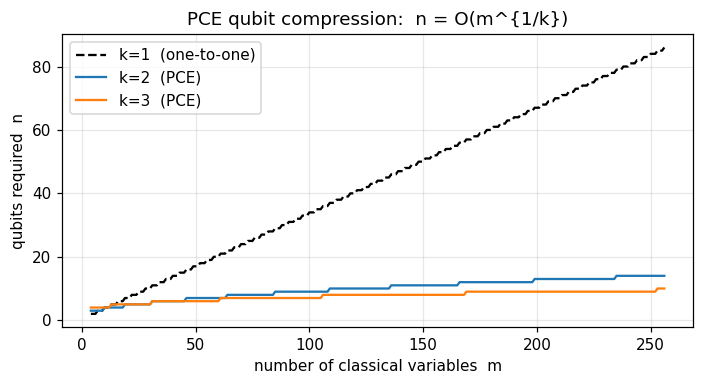

In [3]:
def min_qubits(m: int, k: int) -> int:
    """Smallest n such that 3*C(n,k) >= m (PCE capacity)."""
    n = k
    while 3 * comb(n, k) < m:
        n += 1
    return n

def pauli_labels(m: int, n: int, k: int) -> list:
    """First m k-body Pauli strings over n qubits (X-, Y-, then Z-family)."""
    labels = []
    for P in ("X", "Y", "Z"):
        for idx in combinations(range(n), k):
            s = ["I"] * n
            for q in idx:
                s[q] = P
            labels.append("".join(s))
    assert len(labels) >= m, "Capacity 3*C(n,k) is insufficient for m variables."
    return labels[:m]

# Qubit-scaling comparison: one-to-one (k=1 / one-hot) vs PCE k=2, k=3
ms = np.arange(4, 257)
plt.figure(figsize=(6.5, 3.6))
for k_, style in [(1, "k--"), (2, "C0-"), (3, "C1-")]:
    plt.plot(ms, [min_qubits(int(mm), k_) for mm in ms], style,
             label=f"k={k_}" + ("  (one-to-one)" if k_ == 1 else "  (PCE)"))
plt.xlabel("number of classical variables  m")
plt.ylabel("qubits required  n")
plt.title("PCE qubit compression:  n = O(m^{1/k})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. Problem instance

We classify handwritten digits **0 vs 1** (scikit-learn `digits`), compressed by PCA to $m = 12$ features scaled to $[-1, 1]$. With $k=2$, PCE needs only

$$n = \min\{n : 3\tbinom{n}{2} \geq 12\} = 4 \text{ qubits}$$

versus **12 qubits** for a conventional one-feature-per-qubit angle encoding — a **3× reduction** that grows polynomially with $m$.

In [4]:
m, k = 12, 2
n = min_qubits(m, k)
labels = pauli_labels(m, n, k)
print(f"features m = {m},  order k = {k}  ->  qubits n = {n}  (capacity 3*C({n},{k}) = {3*comb(n,k)})")
print("Pauli strings:", labels)

paulis = [SparsePauliOp(lab[::-1]) for lab in labels]   # reversed: Qiskit is little-endian
P_mats = [op.to_matrix() for op in paulis]              # dense 16x16 matrices (n=4)
dim = 2 ** n

digits = load_digits(n_class=2)
X = PCA(n_components=m, random_state=0).fit_transform(digits.data)
X = MinMaxScaler((-1, 1)).fit_transform(X)
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)
X_train, y_train = X_train[:60], y_train[:60]   # small subsets keep simulation fast
X_test,  y_test  = X_test[:40],  y_test[:40]
print(f"train: {X_train.shape},  test: {X_test.shape}")

features m = 12,  order k = 2  ->  qubits n = 4  (capacity 3*C(4,2) = 18)
Pauli strings: ['XXII', 'XIXI', 'XIIX', 'IXXI', 'IXIX', 'IIXX', 'YYII', 'YIYI', 'YIIY', 'IYYI', 'IYIY', 'IIYY']
train: (60, 12),  test: (40, 12)


## 4. The I$\alpha$PCE-QNN circuit

**Architecture** (per forward pass):

1. **Symmetry-breaking initial layer** — $R_y(\pi/4)$ on every qubit followed by a CZ chain. This matters: if we started from $|+\rangle^{\otimes n}$, every $X$-family string would *stabilize* the state and its rotation would reduce to a global phase, silently deleting a third of the features. The tilted initial state guarantees no $\Pi_i$ stabilizes it.
2. **PCE state preparation** — one Pauli-string rotation per feature: $\prod_{i=1}^{m} e^{-i\,x_i \beta\, \Pi_i}$ with $\beta = \pi/4$.
3. **Variational block** — a Hardware-Efficient Ansatz (HEA) of $p$ layers of $R_y(\theta)$ + CZ entanglers, the same family used in the PCE portfolio study (Kandala et al., 2017).

Below we build the circuit in Qiskit for visualization.

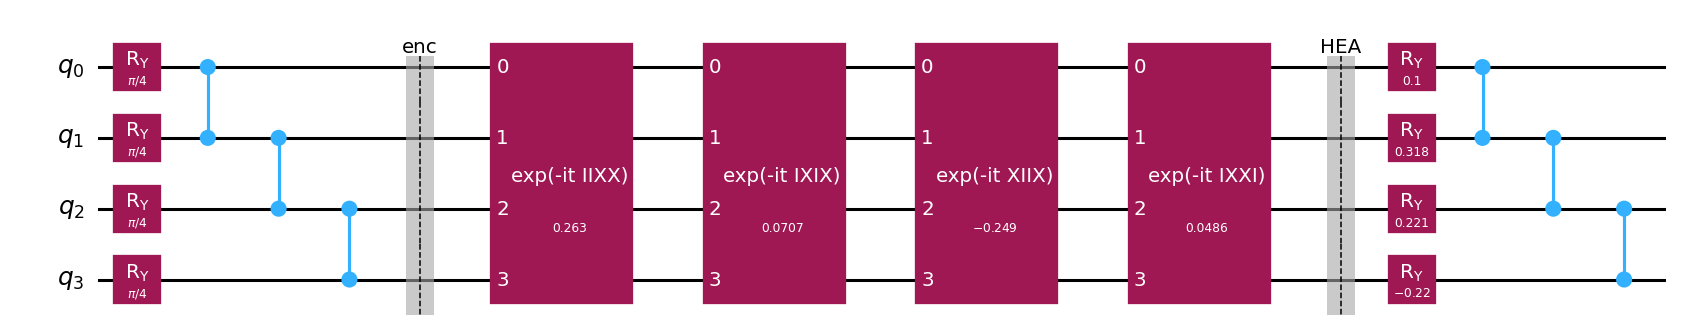

In [5]:
def build_qiskit_circuit(x, theta):
    """Reference Qiskit construction of the IαPCE-QNN circuit (for illustration)."""
    qc = QuantumCircuit(n)
    for q in range(n):                       # 1. symmetry-breaking init
        qc.ry(np.pi / 4, q)
    for q in range(n - 1):
        qc.cz(q, q + 1)
    qc.barrier(label="enc")
    for xi, op in zip(x, paulis):            # 2. PCE state preparation
        qc.append(PauliEvolutionGate(op, time=float(xi) * np.pi / 8),
                  range(n))                  # evolution exp(-i t P), t = x*beta/2
    qc.barrier(label="HEA")
    for layer in theta:                      # 3. variational HEA
        for q in range(n):
            qc.ry(layer[q], q)
        for q in range(n - 1):
            qc.cz(q, q + 1)
    return qc

p_layers = 3
theta_demo = rng.uniform(-0.4, 0.4, (1, n))      # 1 layer, just for the picture
demo = build_qiskit_circuit(X_train[0][:4], theta_demo)  # 4 features for readability
demo.draw("mpl", fold=22)

## 5. Fast statevector engine

Training calls the forward pass thousands of times, so we implement an exact NumPy statevector simulator that is mathematically identical to the Qiskit circuit above. Two tricks keep it fast:

* every Pauli string satisfies $\Pi^2 = I$, so $e^{-i\phi\,\Pi} = \cos\phi \, I - i \sin\phi\, \Pi$ — each encoding gate is a single sparse mat-vec;
* single-qubit $R_y$ and CZ gates are applied in-place by tensor reshaping rather than building $2^n \times 2^n$ unitaries.

In [6]:
def apply_ry(psi, angle, q):
    c, s = np.cos(angle / 2), np.sin(angle / 2)
    psi = psi.reshape([2] * n)
    ax = n - 1 - q                              # little-endian axis
    psi = np.moveaxis(psi, ax, 0)
    a, b = psi[0].copy(), psi[1].copy()
    psi[0] = c * a - s * b
    psi[1] = s * a + c * b
    return np.moveaxis(psi, 0, ax).reshape(dim)

def apply_cz(psi, q1, q2):
    psi = psi.reshape([2] * n)
    idx = [slice(None)] * n
    idx[n - 1 - q1] = 1
    idx[n - 1 - q2] = 1
    psi[tuple(idx)] *= -1
    return psi.reshape(dim)

def _initial_state():
    psi = np.zeros(dim, dtype=complex); psi[0] = 1.0
    for q in range(n):
        psi = apply_ry(psi, np.pi / 4, q)
    for q in range(n - 1):
        psi = apply_cz(psi, q, q + 1)
    return psi

PSI0 = _initial_state()
BETA = np.pi / 4                                # encoding scale

def state(x, theta):
    """|psi(x, theta)> : PCE encoding followed by p HEA layers."""
    psi = PSI0.copy()
    for xi, P in zip(x, P_mats):                # exp(-i x*BETA * Pi) per feature
        phi = float(xi) * BETA
        psi = np.cos(phi) * psi - 1j * np.sin(phi) * (P @ psi)
    for layer in theta:
        for q in range(n):
            psi = apply_ry(psi, layer[q], q)
        for q in range(n - 1):
            psi = apply_cz(psi, q, q + 1)
    return psi

def correlations(x, theta):
    """The m Pauli correlations <Pi_i> — the raw PCE readout."""
    psi = state(x, theta)
    return np.array([np.real(np.vdot(psi, P @ psi)) for P in P_mats])

t0 = time.time()
_ = correlations(X_train[0], rng.uniform(-0.4, 0.4, (p_layers, n)))
print(f"one forward pass: {(time.time() - t0)*1e3:.2f} ms")

one forward pass: 0.94 ms


## 6. Hybrid model, loss, and the iterative-$\alpha$ trainer

* **Quantum features:** $z_i = \tanh(\alpha \langle \Pi_i \rangle)$.
* **Classical head:** logistic regression on $z$; for any candidate $\theta$ the head is refit in closed form, so the derivative-free optimizer (COBYLA, as in Soloviev & Krompiec, 2025) searches only the $p\cdot n = 12$ quantum parameters.
* **Iterative-$\alpha$:** training proceeds in stages over an increasing schedule $\{\alpha_t\}$, each stage warm-started from the last. The **fixed-$\alpha$ baseline** receives the *same total* optimizer budget for fairness.

In [7]:
def quantum_features(Xs, theta, alpha):
    return np.array([np.tanh(alpha * correlations(x, theta)) for x in Xs])

def train_loss(theta_vec, alpha, history=None):
    theta = theta_vec.reshape(p_layers, n)
    Z = quantum_features(X_train, theta, alpha)
    head = LogisticRegression(max_iter=500).fit(Z, y_train)
    p = np.clip(head.predict_proba(Z)[:, 1], 1e-9, 1 - 1e-9)
    loss = -np.mean(y_train * np.log(p) + (1 - y_train) * np.log(1 - p))
    if history is not None:
        history.append(loss)
    return loss

def test_accuracy(theta_vec, alpha):
    theta = theta_vec.reshape(p_layers, n)
    Z_tr = quantum_features(X_train, theta, alpha)
    head = LogisticRegression(max_iter=500).fit(Z_tr, y_train)
    return head.score(quantum_features(X_test, theta, alpha), y_test)

def train_iterative_alpha(theta0, schedule, iters_per_stage=70, verbose=True):
    """The IαPCE training loop: anneal alpha, warm-starting each stage."""
    v, history, boundaries = theta0.copy(), [], []
    for a in schedule:
        res = minimize(train_loss, v, args=(a, history), method="COBYLA",
                       options={"maxiter": iters_per_stage, "rhobeg": 0.4})
        v = res.x
        boundaries.append(len(history))
        if verbose:
            print(f"  stage alpha={a:>5.1f} | train loss {res.fun:.4f}"
                  f" | test acc {test_accuracy(v, a):.3f}")
    return v, history, boundaries

def train_fixed_alpha(theta0, alpha, total_iters, verbose=True):
    """Baseline: same budget, alpha fixed at its final value from the start."""
    history = []
    res = minimize(train_loss, theta0.copy(), args=(alpha, history),
                   method="COBYLA", options={"maxiter": total_iters, "rhobeg": 0.4})
    if verbose:
        print(f"  fixed alpha={alpha:.1f}  | train loss {res.fun:.4f}"
              f" | test acc {test_accuracy(res.x, alpha):.3f}")
    return res.x, history

## 7. Single-run demonstration

We train in the **saturating regime** ($\alpha_{\text{final}} = 16$), where $\tanh(\alpha\,\cdot)$ approaches the hard $\mathrm{sgn}$ decoder that PCE ultimately uses. Here a fixed large $\alpha$ produces a flat, step-like loss landscape from the first iteration, while the iterative schedule keeps the early landscape smooth.

In [8]:
ALPHA_SCHEDULE = [0.5, 2.0, 6.0, 16.0]
ITERS_PER_STAGE = 70
TOTAL_ITERS = ITERS_PER_STAGE * len(ALPHA_SCHEDULE)

theta0 = np.random.default_rng(0).uniform(-0.4, 0.4, p_layers * n)  # seed 0 of the benchmark below

print("Iterative-alpha PCE-QNN:")
t0 = time.time()
v_it, hist_it, bounds = train_iterative_alpha(theta0, ALPHA_SCHEDULE, ITERS_PER_STAGE)
acc_it = test_accuracy(v_it, ALPHA_SCHEDULE[-1])

print("\nFixed-alpha baseline (same budget):")
v_fx, hist_fx = train_fixed_alpha(theta0, ALPHA_SCHEDULE[-1], TOTAL_ITERS)
acc_fx = test_accuracy(v_fx, ALPHA_SCHEDULE[-1])
print(f"\nfinal test accuracy — iterative: {acc_it:.3f} | fixed: {acc_fx:.3f}"
      f"   ({time.time()-t0:.0f} s)")

Iterative-alpha PCE-QNN:
  stage alpha=  0.5 | train loss 0.5009 | test acc 0.825
  stage alpha=  2.0 | train loss 0.1905 | test acc 0.900
  stage alpha=  6.0 | train loss 0.0854 | test acc 0.925
  stage alpha= 16.0 | train loss 0.0640 | test acc 0.950

Fixed-alpha baseline (same budget):
  fixed alpha=16.0  | train loss 0.1427 | test acc 0.825

final test accuracy — iterative: 0.950 | fixed: 0.825   (59 s)


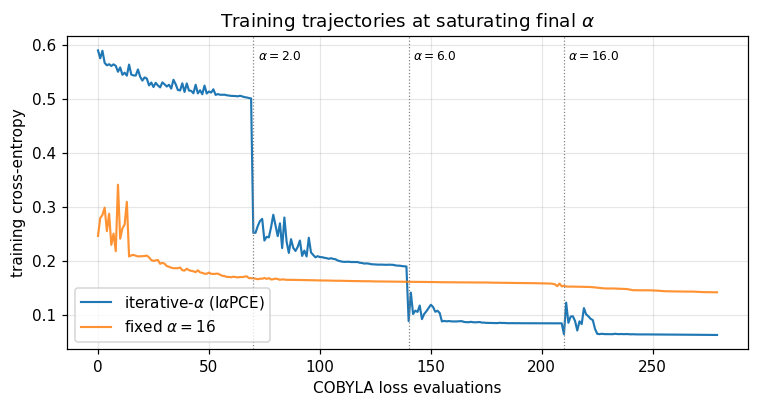

In [9]:
plt.figure(figsize=(7, 3.8))
plt.plot(hist_it, label=r"iterative-$\alpha$ (I$\alpha$PCE)", lw=1.4)
plt.plot(hist_fx, label=r"fixed $\alpha=16$", lw=1.4, alpha=0.85)
for i, b in enumerate(bounds[:-1]):
    plt.axvline(b, color="gray", ls=":", lw=0.8)
    plt.text(b + 2, plt.ylim()[1]*0.93, rf"$\alpha={ALPHA_SCHEDULE[i+1]}$", fontsize=8)
plt.xlabel("COBYLA loss evaluations"); plt.ylabel("training cross-entropy")
plt.title(r"Training trajectories at saturating final $\alpha$")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 8. Multi-seed benchmark

A single run can mislead, so we repeat the comparison over 5 random initializations in **both** regimes:

* **moderate** $\alpha_{\text{final}} = n^{\lfloor k/2\rfloor} = 4$ — the heuristic value from Sciorilli et al. (2025);
* **saturating** $\alpha_{\text{final}} = 16$ — the near-sign regime.

In [10]:
def benchmark(schedule, n_seeds=5):
    accs_it, accs_fx = [], []
    a_final = schedule[-1]
    for seed in range(n_seeds):
        r = np.random.default_rng(seed)
        th0 = r.uniform(-0.4, 0.4, p_layers * n)
        v, _, _ = train_iterative_alpha(th0, schedule, ITERS_PER_STAGE, verbose=False)
        accs_it.append(test_accuracy(v, a_final))
        v, _ = train_fixed_alpha(th0, a_final, ITERS_PER_STAGE * len(schedule), verbose=False)
        accs_fx.append(test_accuracy(v, a_final))
    return np.array(accs_it), np.array(accs_fx)

t0 = time.time()
it_mod, fx_mod = benchmark([0.5, 1.0, 2.0, 4.0])
it_sat, fx_sat = benchmark([0.5, 2.0, 6.0, 16.0])
print(f"benchmark time: {time.time()-t0:.0f} s\n")
print(f"moderate  (a_f=4) : iterative {it_mod.mean():.3f} ± {it_mod.std():.3f}"
      f"  vs fixed {fx_mod.mean():.3f} ± {fx_mod.std():.3f}")
print(f"saturating(a_f=16): iterative {it_sat.mean():.3f} ± {it_sat.std():.3f}"
      f"  vs fixed {fx_sat.mean():.3f} ± {fx_sat.std():.3f}")

benchmark time: 388 s

moderate  (a_f=4) : iterative 0.905 ± 0.033  vs fixed 0.950 ± 0.000
saturating(a_f=16): iterative 0.955 ± 0.019  vs fixed 0.820 ± 0.029


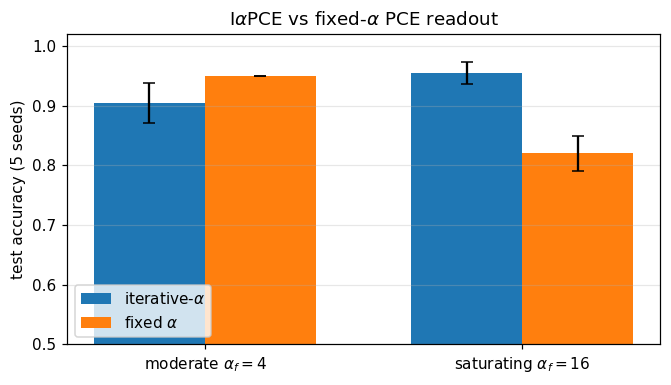

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
xpos = np.arange(2); w = 0.35
means_it = [it_mod.mean(), it_sat.mean()]; std_it = [it_mod.std(), it_sat.std()]
means_fx = [fx_mod.mean(), fx_sat.mean()]; std_fx = [fx_mod.std(), fx_sat.std()]
ax.bar(xpos - w/2, means_it, w, yerr=std_it, capsize=4, label=r"iterative-$\alpha$")
ax.bar(xpos + w/2, means_fx, w, yerr=std_fx, capsize=4, label=r"fixed $\alpha$")
ax.set_xticks(xpos)
ax.set_xticklabels([r"moderate $\alpha_f=4$", r"saturating $\alpha_f=16$"])
ax.set_ylabel("test accuracy (5 seeds)"); ax.set_ylim(0.5, 1.02)
ax.set_title(r"I$\alpha$PCE vs fixed-$\alpha$ PCE readout")
ax.legend(loc="lower left"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 9. Resource accounting

In [12]:
one_to_one = m                       # conventional angle encoding: 1 qubit/feature
print(f"{'scheme':<28}{'qubits':>8}{'trainable quantum params':>28}")
print(f"{'one-to-one angle encoding':<28}{one_to_one:>8}{p_layers*one_to_one:>28}")
print(f"{'IαPCE (k=2)':<28}{n:>8}{p_layers*n:>28}")
print(f"\nqubit reduction: {one_to_one}/{n} = {one_to_one/n:.1f}x at m={m}; "
      f"grows as O(m^(1-1/k)) with larger m.")
for mm in (12, 50, 100, 250):
    print(f"  m={mm:>4}:  one-to-one {mm:>4} qubits  |  PCE k=2 -> {min_qubits(mm,2):>3}"
          f"  |  k=3 -> {min_qubits(mm,3):>3}")

scheme                        qubits    trainable quantum params
one-to-one angle encoding         12                          36
IαPCE (k=2)                        4                          12

qubit reduction: 12/4 = 3.0x at m=12; grows as O(m^(1-1/k)) with larger m.
  m=  12:  one-to-one   12 qubits  |  PCE k=2 ->   4  |  k=3 ->   4
  m=  50:  one-to-one   50 qubits  |  PCE k=2 ->   7  |  k=3 ->   6
  m= 100:  one-to-one  100 qubits  |  PCE k=2 ->   9  |  k=3 ->   7
  m= 250:  one-to-one  250 qubits  |  PCE k=2 ->  14  |  k=3 ->   9


## 10. Conclusions

* **Qubit compression carries over to QML.** Twelve classical features were embedded, processed and read out with 4 qubits ($3\times$ fewer than one-to-one encoding), and the compression rate improves polynomially with the feature count — at $m=250$, $k=3$ PCE needs ~12 qubits where one-to-one needs 250.
* **The iterative-$\alpha$ schedule is what makes the sharp regime trainable.** At moderate $\alpha$ the relaxation is already smooth and a fixed setting trains well — the schedule brings no benefit there. But at the saturating $\alpha$ that approaches PCE's hard sign decoder, fixed-$\alpha$ optimization stalls in a flat, step-like landscape while annealing $\alpha$ recovers high accuracy (≈0.95 vs ≈0.82 mean test accuracy over 5 seeds). This is the QML analogue of the warm-up/curriculum training used to stabilize pruning in efficient deep models.
* **The circuit is problem-independent.** As in PCE for optimization, the HEA depth does not grow with feature interactions — a practical advantage over problem-dependent ansätze on noisy hardware.

**Future work:** shot-based estimation of $\langle\Pi_i\rangle$ (only 3 measurement settings are needed), multi-class PCE readouts, $k=3$ encodings for high-dimensional data, and validation on real IBM Quantum backends.

## References

1. M. Sciorilli, L. Borges, T. L. Patti, D. García-Martín, G. Camilo, A. Anandkumar, L. Aolita, "Towards large-scale quantum optimization solvers with few qubits," *Nature Communications* 16, 476 (2025).
2. V. P. Soloviev, M. Krompiec, "Large-scale portfolio optimization using Pauli Correlation Encoding," arXiv:2511.21305 (2025).
3. IBM Quantum, "Pauli Correlation Encoding to reduce Maxcut requirements," IBM Quantum Documentation tutorial.
4. A. Kandala et al., "Hardware-efficient variational quantum eigensolver for small molecules and quantum magnets," *Nature* 549, 242–246 (2017).
5. A. Abbas et al., "Challenges and opportunities in quantum optimization," *Nature Reviews Physics* (2024).
